In [ ]:
# !pip install xgboost lightgbm catboost

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier, Pool

sns.set(style="whitegrid")

# Load and clean dataset
df = pd.read_csv("adult_income.csv")
for col in df.select_dtypes(include='object'):
    df[col] = df[col].str.strip()

df['income'] = LabelEncoder().fit_transform(df['income'])

# Encode features
X = pd.get_dummies(df.drop(columns='income'))
y = df['income']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [2]:
# XGBoost
xgb_model = xgb.XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

# LightGBM
lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(X_train, y_train)
lgb_preds = lgb_model.predict(X_test)

# CatBoost (no need to scale or encode, but we use same data here for consistency)
cat_model = CatBoostClassifier(verbose=0, random_state=42)
cat_model.fit(X_train, y_train)
cat_preds = cat_model.predict(X_test)


/Users/sandilranasinghe/Work/workshops/datastorm/code/venv/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [17:57:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Info] Number of positive: 6270, number of negative: 19778
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004244 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 842
[LightGBM] [Info] Number of data points in the train set: 26048, number of used features: 89
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.240709 -> initscore=-1.148794
[LightGBM] [Info] Start training from score -1.148794


In [3]:
models = {
    "XGBoost": xgb_preds,
    "LightGBM": lgb_preds,
    "CatBoost": cat_preds
}

for name, preds in models.items():
    print(f"🔍 {name}")
    print("Accuracy:", accuracy_score(y_test, preds))
    print("Classification Report:")
    print(classification_report(y_test, preds))
    print("=" * 50)


🔍 XGBoost
Accuracy: 0.8759404268386304
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      4942
           1       0.78      0.67      0.72      1571

    accuracy                           0.88      6513
   macro avg       0.84      0.81      0.82      6513
weighted avg       0.87      0.88      0.87      6513

🔍 LightGBM
Accuracy: 0.8793182865039152
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      4942
           1       0.79      0.68      0.73      1571

    accuracy                           0.88      6513
   macro avg       0.85      0.81      0.83      6513
weighted avg       0.88      0.88      0.88      6513

🔍 CatBoost
Accuracy: 0.8787041302011361
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      4942
           1       0.79      0.67      0.73      

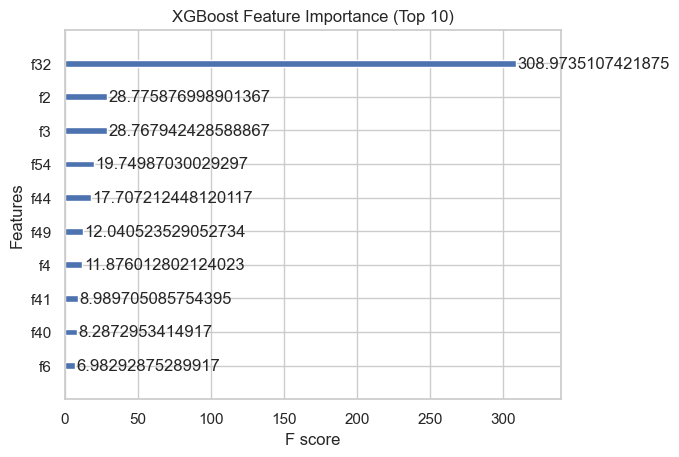

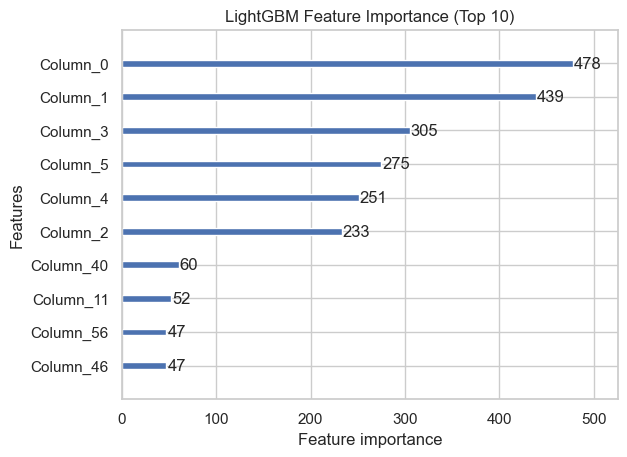

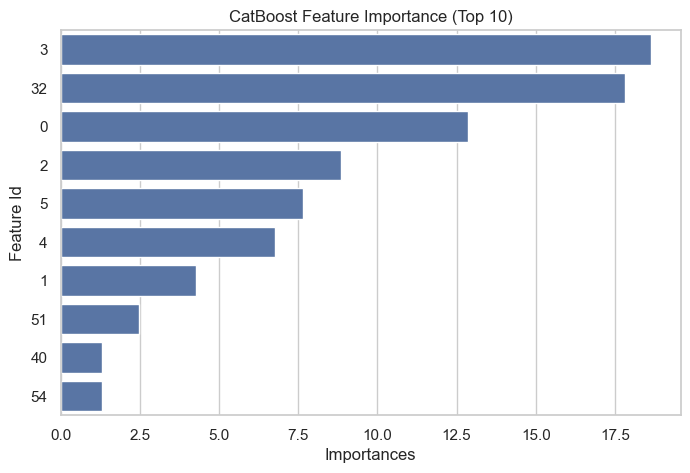

In [4]:
# XGBoost
xgb.plot_importance(xgb_model, max_num_features=10, importance_type='gain')
plt.title("XGBoost Feature Importance (Top 10)")
plt.show()

# LightGBM
lgb.plot_importance(lgb_model, max_num_features=10)
plt.title("LightGBM Feature Importance (Top 10)")
plt.show()

# CatBoost (built-in method)
cat_importance = cat_model.get_feature_importance(prettified=True).head(10)
plt.figure(figsize=(8, 5))
sns.barplot(x='Importances', y='Feature Id', data=cat_importance)
plt.title("CatBoost Feature Importance (Top 10)")
plt.show()
